# Experiment 7: Fuzzy Membership Functions
**Name:** Arshan Attar  
**Roll Number:** 231408  

In [10]:
import numpy as np
import matplotlib.pyplot as plt

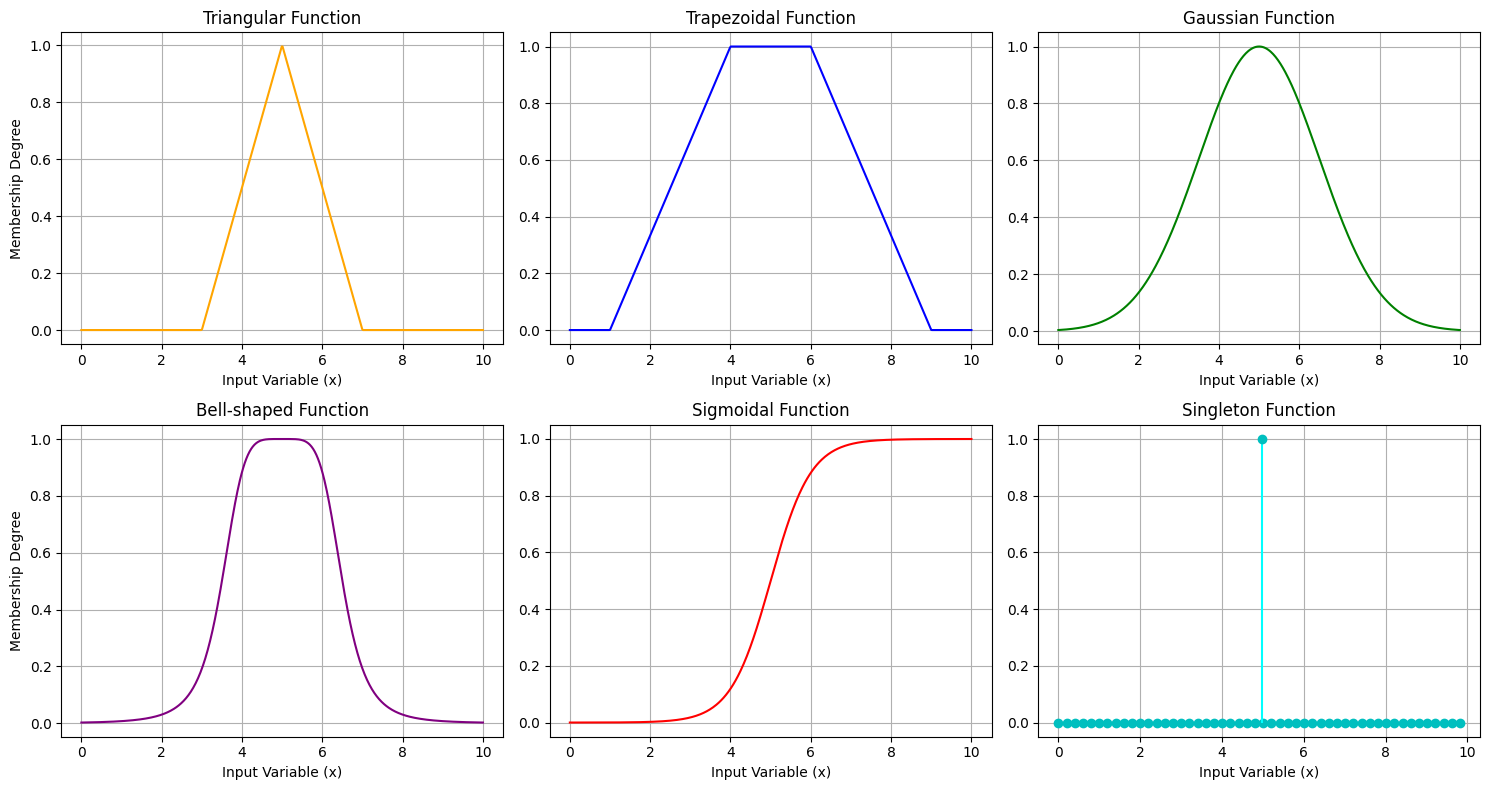

In [13]:
# 1. ADD MISSING IMPORTS
import numpy as np
import matplotlib.pyplot as plt

# 1. Triangular Membership Function
def triangular(x, a, b, c):
    """ a: left base, b: peak, c: right base """
    y = np.zeros(len(x))
    for i in range(len(x)):
        if x[i] <= a or x[i] >= c:
            y[i] = 0.0
        elif a < x[i] <= b:
            y[i] = (x[i] - a) / (b - a)
        elif b < x[i] < c:
            y[i] = (c - x[i]) / (c - b)
    return y

# 2. Trapezoidal Membership Function
def trapezoidal(x, a, b, c, d):
    """ a: left base, b: left top, c: right top, d: right base """
    y = np.zeros(len(x))
    for i in range(len(x)):
        if x[i] <= a or x[i] >= d:
            y[i] = 0.0
        elif a < x[i] <= b:
            y[i] = (x[i] - a) / (b - a)
        elif b < x[i] <= c:
            y[i] = 1.0
        elif c < x[i] < d:
            y[i] = (d - x[i]) / (d - c)
    return y

# 3. Gaussian Membership Function
def gaussian(x, mean, sigma):
    """ mean: center of the peak, sigma: width of the bell """
    return np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# 4. Generalized Bell-shaped Membership Function
def bell_shaped(x, a, b, c):
    """
    a: width of the curve
    b: slope/shape parameter (positive)
    c: center of the curve
    """
    return 1.0 / (1.0 + np.abs((x - c) / a) ** (2 * b))

# 5. Sigmoidal Membership Function
def sigmoidal(x, a, c):
    """
    a: steepness (positive = opens right, negative = opens left)
    c: crossover point (where membership degree is 0.5)
    """
    return 1.0 / (1.0 + np.exp(-a * (x - c)))

# 6. Singleton Membership Function
def singleton(x, c):
    """
    c: exact point where membership is 1.0
    """
    y = np.zeros(len(x))
    idx = (np.abs(x - c)).argmin()
    y[idx] = 1.0
    return y

# Set up the universe of discourse (X-axis range from 0 to 10)
x = np.linspace(0, 10, 500)

# Calculate membership values (Y-axis)
y_tri = triangular(x, 3, 5, 7)
y_trap = trapezoidal(x, 1, 4, 6, 9)
y_gauss = gaussian(x, 5, 1.5)
y_bell = bell_shaped(x, a=1.5, b=2.5, c=5)
y_sig = sigmoidal(x, a=2.0, c=5)
y_sing = singleton(x, c=5)

# 2. INCREASE FIGURE SIZE FOR 6 PLOTS
plt.figure(figsize=(15, 8))

# Triangular Plot (Row 1, Col 1)
plt.subplot(2, 3, 1)
plt.plot(x, y_tri, label='Triangular', color='orange')
plt.title('Triangular Function')
plt.xlabel('Input Variable (x)')
plt.ylabel('Membership Degree')
plt.grid(True)

# Trapezoidal Plot (Row 1, Col 2)
plt.subplot(2, 3, 2)
plt.plot(x, y_trap, label='Trapezoidal', color='blue')
plt.title('Trapezoidal Function')
plt.xlabel('Input Variable (x)')
plt.grid(True)

# Gaussian Plot (Row 1, Col 3)
plt.subplot(2, 3, 3)
plt.plot(x, y_gauss, label='Gaussian', color='green')
plt.title('Gaussian Function')
plt.xlabel('Input Variable (x)')
plt.grid(True)

# Bell-shaped Plot (Row 2, Col 1)
plt.subplot(2, 3, 4)
plt.plot(x, y_bell, label='Bell-shaped', color='purple')
plt.title('Bell-shaped Function')
plt.xlabel('Input Variable (x)')
plt.ylabel('Membership Degree')
plt.grid(True)

# Sigmoidal Plot (Row 2, Col 2)
plt.subplot(2, 3, 5)
plt.plot(x, y_sig, label='Sigmoidal', color='red')
plt.title('Sigmoidal Function')
plt.xlabel('Input Variable (x)')
plt.grid(True)

# Singleton Plot (Row 2, Col 3)
plt.subplot(2, 3, 6)
plt.stem(x[::10], y_sing[::10], linefmt='cyan', markerfmt='co', basefmt=' ')
idx = (np.abs(x - 5)).argmin()
plt.stem([x[idx]], [y_sing[idx]], linefmt='cyan', markerfmt='co', basefmt=' ')
plt.title('Singleton Function')
plt.xlabel('Input Variable (x)')
plt.grid(True)

plt.tight_layout()
plt.show()

### What are these 'Membership Functions'?
Think of it like this: if I ask 'Is someone tall?', it's not always a clear yes or no. A 7-foot person is definitely tall, but what about a 5'9" person? Fuzzy logic lets us say someone is 'partially tall'. These functions help us define that 'partial' membership, usually from 0 (not at all) to 1 (fully).

Here are the types of membership functions I've implemented and plotted:

1.  **Triangular Function:**
    *   Imagine a triangle. Its value starts at 0, goes up to 1 at a peak, and then comes back down to 0. It's defined by three points: where it starts (left base), its peak, and where it ends (right base).
    *   In the code, I set `a=3`, `b=5`, and `c=7`. This means the 'fuzzy' concept starts at 3, is fully 'true' at 5, and ends at 7.

2.  **Trapezoidal Function:**
    *   This is like a triangle but with a flat top, so it looks like a trapezoid. It starts at 0, goes up to 1, stays at 1 for a while, and then drops back to 0.
    *   It needs four points: `a` (left base), `b` (start of the flat top), `c` (end of the flat top), and `d` (right base). So, it's fully 'true' between `b` and `c`.
    *   I used `a=1`, `b=4`, `c=6`, `d=9` for this one.

3.  **Gaussian Function:**
    *   This one is a smooth, bell-shaped curve, like the one we see in statistics for normal distributions. It's very smooth and doesn't have sharp corners like the triangle or trapezoid.
    *   It's defined by a `mean` (where its peak is) and a `sigma` (how wide or spread out it is).
    *   My plot has a `mean` of 5 and a `sigma` of 1.5, making a nice bell shape centered at 5.

4.  **Generalized Bell-shaped Function:**
    *   This is another bell-shaped curve, but it's a bit more flexible than the Gaussian. We can adjust its shape with three parameters: `a` (which affects its width), `b` (which makes it more or less curvy or 'sloped'), and `c` (its center).
    *   I've set `a=1.5`, `b=2.5`, and `c=5` to see how it looks.

5.  **Sigmoidal Function:**
    *   This function creates an 'S' shaped curve. It's useful for representing things that transition smoothly from 'not true' to 'true'.
    *   It has two parameters: `a` (how steep the 'S' is) and `c` (the point where the membership is exactly 0.5).
    *   My example uses `a=2.0` (a good steepness) and `c=5` (the transition point).

6.  **Singleton Function:**
    *   This is the simplest one! It means membership is 1.0 at *exactly one point* and 0 everywhere else. It's like saying 'only this specific value is true'.
    *   It's defined by `c`, the exact point where its membership is 1.0. I chose `c=5`, so only the value 5 has a membership of 1.

### How I Plotted Them:

*   First, I set up a range of numbers from 0 to 10 (that's `x = np.linspace(0, 10, 500)`). This is our 'universe of discourse' – all the possible input values we're considering. The `500` means we're using 500 small steps to make the curves smooth.
*   Then, for each function, I calculated the `y` values (the 'membership degree') using the `x` values and the specific parameters for each function.
*   Finally, I used `matplotlib.pyplot` to draw all these functions. I put them in a `2x3` grid, so six plots fit nicely on one page. Each plot has a title, labels for the x and y axes, and a grid to make it easy to read. I also used `plt.tight_layout()` to make sure all the labels and titles fit without overlapping.

So, this code helps visualize how different fuzzy membership functions work and how they can represent concepts that aren't strictly black or white, but rather shades of gray!